In [45]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
bills_actions = pd.read_csv("data_raw/bills_actions.csv")
bills_actions.dtypes

Congress        int64
bill_number     int64
bill_type      object
action         object
main_action    object
category       object
member_id       int64
dtype: object

# Q1: How many distinct “bill” identifiers are there? 

In [4]:
num_distinct_bills =bills_actions['bill_number'].nunique()
print(num_distinct_bills)

1331


I use nunique() to get distinct bill numbers, and there are 1331 different bill numbers

# What proportion of the rows belong to different categories? 

In [29]:
print(bills_actions["category"].value_counts())

category_proportion =bills_actions["category"].value_counts(normalize=True)
print(category_proportion)

category
amendment                       1529
house bill                       902
senate bill                      514
house resolution                 234
senate resolution                 60
house joint resolution            22
house concurrent resolution       20
senate concurrent resolution      14
senate joint resolution            8
Name: count, dtype: int64
category
amendment                       0.462913
house bill                      0.273085
senate bill                     0.155616
house resolution                0.070845
senate resolution               0.018165
house joint resolution          0.006661
house concurrent resolution     0.006055
senate concurrent resolution    0.004239
senate joint resolution         0.002422
Name: proportion, dtype: float64


I use value_counts(normalize=True) to get the proportion.

# Within each category, calculate the proportion of rows that belongs to different “main_action”.

In [11]:
print(bills_actions["main_action"].unique())
category_list = bills_actions["category"].unique()  #list of category
action_list = bills_actions["main_action"].unique() #list of main action
results =  [] # create a  list to store info

for category in category_list:
    subset = bills_actions[bills_actions["category"] == category] #subset each category
    proportion = subset["main_action"].value_counts(normalize=True)  # Compute proportion within each category
    for action, proportion in zip(action_list,proportion.values): 
        results.append({
            "category": category,
            "main_action": action,
            "proportion": proportion
        })
proportion_df = pd.DataFrame(results)
print(proportion_df.head(10))

['senate amendment proposed (on the floor)'
 'senate committee/subcommittee actions'
 'senate committee report filed after reporting' 'senate floor actions'
 'reported to senate' 'other senate amendment actions'
 'house floor actions' 'house committee/subcommittee actions'
 'house amendment offered' 'resolving differences -- house actions'
 'other house amendment actions' 'house discharge petition filed'
 'resolving differences -- senate actions']
      category                                    main_action  proportion
0    amendment       senate amendment proposed (on the floor)    0.541530
1    amendment          senate committee/subcommittee actions    0.259647
2    amendment  senate committee report filed after reporting    0.187050
3    amendment                           senate floor actions    0.011772
4  senate bill       senate amendment proposed (on the floor)    0.651751
5  senate bill          senate committee/subcommittee actions    0.225681
6  senate bill  senate committ

I use a for loop:for each category, compute proportion of different actions and then add info to a list

# Q2:How many house floor actions are there as part of senate bills (category)?


In [12]:
subset_house_floor = bills_actions[
    (bills_actions["category"] == "senate bill") &
    (bills_actions["main_action"] == "house floor actions")
]
print(len(subset_house_floor))

116


There are 116 floor actions

# What proportion of these actions were suspended? What proportion of these actions were suspended as amended?

In [27]:
suspend = subset_house_floor["action"].str.contains("suspend", case=False, na=False)
print(suspend)
print(suspend.value_counts())
suspend.mean() # proportion = 80/(80+36)

559    False
560    False
562    False
563    False
564    False
       ...  
790     True
792     True
794     True
796     True
798     True
Name: action, Length: 116, dtype: bool
action
True     80
False    36
Name: count, dtype: int64


0.6896551724137931

I use str.contains() to filter all rows with "suspend" and the proportion is 0.6896

In [28]:
both = (
    subset_house_floor["action"].str.contains("suspend", case=False, na=False)
    & subset_house_floor["action"].str.contains("amend", case=False, na=False)
)
print(both.value_counts())
both.mean()

action
False    98
True     18
Name: count, dtype: int64


0.15517241379310345

I use str.contains() to filter all rows with "suspend"&"amend" and the proportion is 0.1551

# Q: Use regular expressions to extract the name of specific people.

In [38]:
subset_house_floor["person"]=subset_house_floor["action"].str.findall(r'\b(?:Mr|Ms|Mrs)\.\s+([A-Z][a-zA-Z]+)')

C:\Users\Zach\AppData\Local\Temp\ipykernel_6056\3870972729.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_house_floor["person"]=subset_house_floor["action"].str.findall(r'\b(?:Mr|Ms|Mrs)\.\s+([A-Z][a-zA-Z]+)')


# Produce a new dataset counting how many bills mention the same person and extracting the names of the people mentioned. What is the distribution of total bills proposed per person?

In [40]:
subset_house_floor["person"].value_counts()

person
[Takano]        9
[Haaland]       6
[Dingell]       6
[Kelly]         5
[Bass]          5
[Pallone]       5
[Case]          5
[Norton]        4
[Cicilline]     4
[DeFazio]       4
[Huffman]       4
[Grijalva]      3
[Scanlon]       3
[Luria]         3
[Carbajal]      3
[Craig]         2
[Horn]          2
[Clay]          2
[Waters]        2
[Jackson]       2
[Peterson]      2
[McBath]        2
[Raskin]        2
[Sherman]       2
[Nadler]        1
[Correa]        1
[Cleaver]       1
[Torres]        1
[McNerney]      1
[Tonko]         1
[Cohen]         1
[Cisneros]      1
[Cummings]      1
[Larson]        1
[Neguse]        1
[Lee]           1
[Lofgren]       1
[Engel]         1
[McAdams]       1
[Eshoo]         1
[Rouda]         1
[Stevens]       1
[Khanna]        1
[Evans]         1
[Sires]         1
[Connolly]      1
[Adams]         1
[Titus]         1
[Gomez]         1
[Kuster]        1
[Larsen]        1
[DeGette]       1
[Perlmutter]    1
Name: count, dtype: int64

In [44]:
counts_df = subset_house_floor["person"].explode().value_counts().to_frame("n_mentions")
counts_df.head(10)

,n_mentions
person,
Takano,9
Haaland,6
Dingell,6
Kelly,5
Bass,5
Pallone,5
Case,5
Norton,4
Cicilline,4


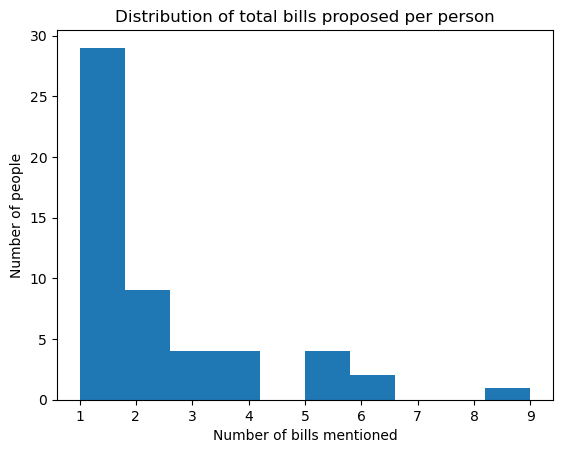

In [48]:
counts_df["n_mentions"].plot(kind="hist")
plt.xlabel("Number of bills mentioned")
plt.ylabel("Number of people")
plt.title("Distribution of total bills proposed per person")
plt.show()

most people only propose 1 bill, only few propose more than 3 bills.

# Q3:focus a subset of bills whose actions are marked as “senate amendment proposed (on the floor)”

In [50]:
subset_senate = bills_actions[bills_actions["main_action"]=="senate amendment proposed (on the floor)"]
subset_senate.head()

,Congress,bill_number,bill_type,action,main_action,category,member_id
0,116,1029,s,S.Amdt.1274 Amendment SA 1274 proposed by Sena...,senate amendment proposed (on the floor),amendment,858
1,116,1031,s,S.Amdt.2698 Amendment SA 2698 proposed by Sena...,senate amendment proposed (on the floor),amendment,675
2,116,1160,s,S.Amdt.2659 Amendment SA 2659 proposed by Sena...,senate amendment proposed (on the floor),amendment,858
8,116,1253,s,S.Amdt.2424 Amendment SA 2424 proposed by Sena...,senate amendment proposed (on the floor),amendment,297
11,116,1309,s,S.Amdt.1275 Amendment SA 1275 proposed by Sena...,senate amendment proposed (on the floor),amendment,858


In [53]:
print(subset_senate["action"].str.findall(
    r"\bSenator\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+)?)"
))
subset_senate["senators"] = subset_senate["action"].str.findall(
    r"\bSenator\s+([A-Z][a-zA-Z]+(?:\s+[A-Z][a-zA-Z]+)?)"
)

0       [McConnell, Cornyn]
1                  [Hawley]
2        [McConnell, Smith]
8       [Feinstein, Cornyn]
11      [McConnell, Cardin]
               ...         
2947              [Johnson]
2948               [Murray]
2949                 [Paul]
3155            [McConnell]
3156            [McConnell]
Name: action, Length: 286, dtype: object


C:\Users\Zach\AppData\Local\Temp\ipykernel_6056\656521058.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_senate["senators"] = subset_senate["action"].str.findall(


In [54]:
subset_senate["n_senators"] = subset_senate["senators"].str.len()
subset_senate["Senator_1"] = subset_senate["senators"].str[0]
subset_senate["Senator_2"] = subset_senate["senators"].str[1]
senator_bill_df = subset_senate[[
    "bill_number", "n_senators", "Senator_1", "Senator_2"
]]
print(senator_bill_df)

      bill_number  n_senators  Senator_1 Senator_2
0            1029           2  McConnell    Cornyn
1            1031           1     Hawley       NaN
2            1160           2  McConnell     Smith
8            1253           2  Feinstein    Cornyn
11           1309           2  McConnell    Cardin
...           ...         ...        ...       ...
2947         6201           1    Johnson       NaN
2948         6201           1     Murray       NaN
2949         6201           1       Paul       NaN
3155         8337           1  McConnell       NaN
3156         8337           1  McConnell       NaN

[286 rows x 4 columns]


C:\Users\Zach\AppData\Local\Temp\ipykernel_6056\1785173778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_senate["n_senators"] = subset_senate["senators"].str.len()
C:\Users\Zach\AppData\Local\Temp\ipykernel_6056\1785173778.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_senate["Senator_1"] = subset_senate["senators"].str[0]
C:\Users\Zach\AppData\Local\Temp\ipykernel_6056\1785173778.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

# What is the distribution of number of senators per bill?

In [55]:
senator_bill_df["n_senators"].value_counts()

n_senators
2    196
1     90
Name: count, dtype: int64

196 bills have 2 senators, 90 bills have only 1 senator.

In [56]:
coauthor_df = senator_bill_df.dropna(subset=["Senator_2"]) # drop those bills with only 1 senator
coauthor_counts = (
    coauthor_df.groupby("Senator_1")["Senator_2"]
               .nunique())
print(coauthor_counts)

Senator_1
Braun         5
Cornyn        9
Cramer        7
Feinstein     1
Fischer       2
Grassley      1
Hawley        1
Inhofe        1
Lee           3
McConnell    57
Menendez      1
Moran         4
Murkowski     6
Perdue        1
Reed         25
Rubio         1
Sasse         2
Scott FL      1
Scott SC      1
Sullivan      2
Thune         3
Name: Senator_2, dtype: int64


Most senators coauthor few people(less than 5) - only 2 senator coauthor more than 10 (McConnell-57,Reed-25)